# Regresión Binaria

## Preparación Datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
from matplotlib import pyplot
from scipy import optimize
import pandas as pd
%matplotlib inline

# Cargar dataset
data = pd.read_csv('/content/drive/MyDrive/SIS420/datasets/datasets_practicos/data_banknote_authentication.csv')

print(data.head())
print(data.dtypes)
print(data.shape)
print(data.isnull().sum())

   Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  Image_Entropy  Class
0           3.62160            8.6661           -2.8073       -0.44699      0
1           4.54590            8.1674           -2.4586       -1.46210      0
2           3.86600           -2.6383            1.9242        0.10645      0
3           3.45660            9.5228           -4.0112       -3.59440      0
4           0.32924           -4.4552            4.5718       -0.98880      0
Variance_Wavelet    float64
Skewness_Wavelet    float64
Curtosis_Wavelet    float64
Image_Entropy       float64
Class                 int64
dtype: object
(1372, 5)
Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64


In [5]:
print(data.columns.tolist())
print(data.head())

['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet', 'Image_Entropy', 'Class']
   Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  Image_Entropy  Class
0           3.62160            8.6661           -2.8073       -0.44699      0
1           4.54590            8.1674           -2.4586       -1.46210      0
2           3.86600           -2.6383            1.9242        0.10645      0
3           3.45660            9.5228           -4.0112       -3.59440      0
4           0.32924           -4.4552            4.5718       -0.98880      0


In [9]:
# El dataset ya es numérico, no tiene nulos ni categóricas
# Solo verificamos que la columna objetivo esté correcta
print(data['Class'].value_counts())

print("Tamaño daatset:", data.shape)

X = data.drop('Class', axis=1)
y = data['Class']

X = X.values
y = y.values

print("X:", X.shape)  # (1372, 4)
print("y:", y.shape)  # (1372,)

Class
0    762
1    610
Name: count, dtype: int64
Tamaño daatset: (1372, 5)
X: (1372, 4)
y: (1372,)


## Gráfico de clases

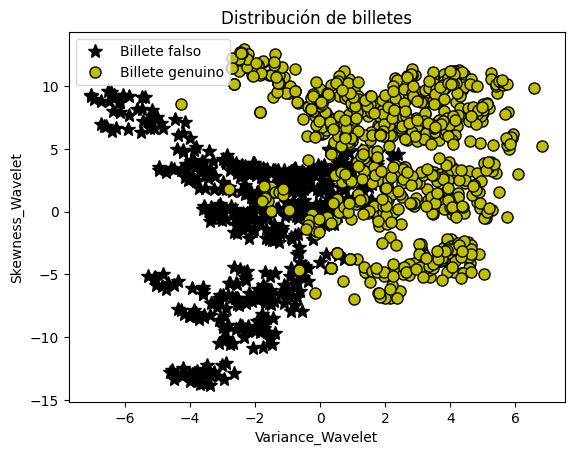

In [10]:
def plotData(X, y):
    fig = pyplot.figure()

    pos = y == 1
    neg = y == 0

    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

    pyplot.xlabel("Variance_Wavelet")
    pyplot.ylabel("Skewness_Wavelet")

X_plot = X[:, :2]
y_plot = y

plotData(X_plot, y_plot)
pyplot.legend(['Billete falso', 'Billete genuino'])
pyplot.title('Distribución de billetes')
pyplot.show()

## Procesamiento de datos

In [11]:
X = X.astype(float)
y = y.astype(float)

def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

# Agregar columna de unos (bias)
m, n = X.shape
X = np.concatenate([np.ones((m, 1)), X], axis=1)

n_features = X.shape[1]
initial_theta = np.zeros(n_features)

print("n_features:", n_features)
print("initial_theta shape:", initial_theta.shape)

n_features: 5
initial_theta shape: (5,)


## Entrenar el modelo

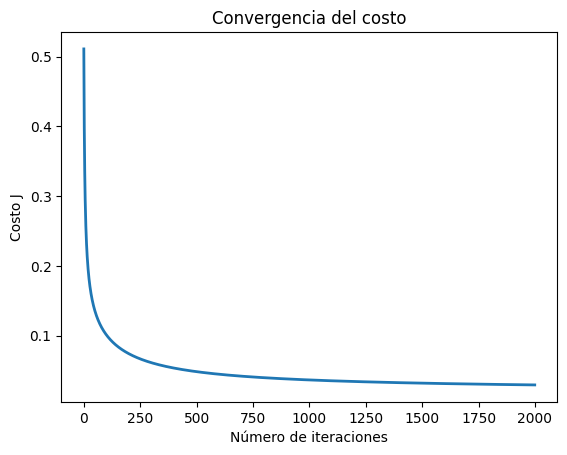

Theta calculado: [ 2.73189694 -2.58531111 -1.50094001 -1.78171635 -0.15675979]


In [14]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))
    J = (1/m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta))
        theta = theta - (alpha / m) * (X.T.dot(h - y))
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

alpha = 0.1
num_iters = 2000

theta = np.zeros(X.shape[1])
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')
pyplot.show()

print("Theta calculado:", theta)

## Revisión Predicción

In [15]:
ejemplo = X[0]
prob = sigmoid(np.dot(ejemplo, theta))

print("Probabilidad de billete falso:", round(prob * 100, 2), "%")

pred = prob >= 0.5
if pred:
    print("Predicción: ⚠ Billete FALSO")
else:
    print("Predicción: ✓ Billete GENUINO")

predicciones = sigmoid(X.dot(theta)) >= 0.5
accuracy = np.mean(predicciones == y) * 100
print("Accuracy del modelo:", round(accuracy, 2), "%")

Probabilidad de billete falso: 0.0 %
Predicción: ✓ Billete GENUINO
Accuracy del modelo: 99.05 %


## Scipy.optimize

In [16]:
def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta))

    epsilon = 1e-8
    h = np.clip(h, epsilon, 1 - epsilon)

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    grad = (1 / m) * X.T.dot(h - y)

    return J, grad

test_theta = np.zeros(n_features)
test_theta[0] = -24
test_theta[1:] = 0.2

cost, grad = costFunction(test_theta, X, y)
print('Costo en theta prueba: {:.3f}'.format(cost))

columnas_X = ['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet', 'Image_Entropy']
print('\nGradiente por feature:')
for i, feat in enumerate(columnas_X):
    print('\t{}: {:.4f}'.format(feat, grad[i + 1]))

Costo en theta prueba: 8.190

Gradiente por feature:
	Variance_Wavelet: 0.8307
	Skewness_Wavelet: 0.4418
	Curtosis_Wavelet: -0.9551
	Image_Entropy: 0.5543


In [17]:
options = {'maxfun': 1000}

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X, y),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta = res.x

print('Costo optimizado: {:.3f}'.format(cost))
print('Estado:', res.message)

columnas_X = ['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet', 'Image_Entropy']
theta_features = list(zip(['bias'] + columnas_X, theta))
theta_ordenado = sorted(theta_features, key=lambda x: abs(x[1]), reverse=True)

print('\nFeatures más influyentes:')
for nombre, valor in theta_ordenado:
    print('\t{}: {:.4f}'.format(nombre, valor))

Costo optimizado: 0.018
Estado: Converged (|f_n-f_(n-1)| ~= 0)

Features más influyentes:
	Variance_Wavelet: -7.8570
	bias: 7.3198
	Curtosis_Wavelet: -5.2862
	Skewness_Wavelet: -4.1902
	Image_Entropy: -0.6057


## Frontera de Decisión

Features seleccionadas: Variance_Wavelet (-7.8570), Curtosis_Wavelet (-5.2862)


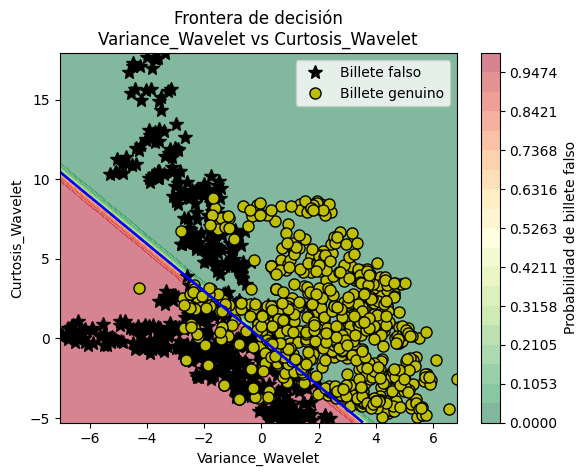

In [18]:
def plotDecisionBoundary(theta, X, y):
    columnas_X = ['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet', 'Image_Entropy']

    theta_features = list(zip(columnas_X, theta[1:]))
    theta_ordenado = sorted(theta_features, key=lambda x: abs(x[1]), reverse=True)

    feat1, val1 = theta_ordenado[0]
    feat2, val2 = theta_ordenado[1]
    print(f"Features seleccionadas: {feat1} ({val1:.4f}), {feat2} ({val2:.4f})")

    idx1 = columnas_X.index(feat1) + 1
    idx2 = columnas_X.index(feat2) + 1

    fig = pyplot.figure()
    pos = y == 1
    neg = y == 0
    pyplot.plot(X[pos, idx1], X[pos, idx2], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, idx1], X[neg, idx2], 'ko', mfc='y', ms=8, mec='k', mew=1)

    f1_range = np.linspace(X[:, idx1].min(), X[:, idx1].max(), 100)
    f2_range = np.linspace(X[:, idx2].min(), X[:, idx2].max(), 100)

    z = np.zeros((len(f1_range), len(f2_range)))
    x_base = np.mean(X, axis=0).copy()

    for i, v1 in enumerate(f1_range):
        for j, v2 in enumerate(f2_range):
            x_temp = x_base.copy()
            x_temp[idx1] = v1
            x_temp[idx2] = v2
            z[i, j] = sigmoid(np.dot(x_temp, theta))

    z = z.T
    pyplot.contourf(f1_range, f2_range, z,
                    levels=np.linspace(0, 1, 20),
                    cmap='RdYlGn_r', alpha=0.5)
    pyplot.colorbar(label='Probabilidad de billete falso')
    pyplot.contour(f1_range, f2_range, z,
                   levels=[0.5], linewidths=2, colors='blue')
    pyplot.xlabel(feat1)
    pyplot.ylabel(feat2)
    pyplot.title(f'Frontera de decisión\n{feat1} vs {feat2}')
    pyplot.legend(['Billete falso', 'Billete genuino'])
    pyplot.show()

plotDecisionBoundary(theta, X, y)

## Predicciones

In [19]:
def predict(theta, X):
    return (sigmoid(X.dot(theta)) >= 0.5).astype(int)

p = predict(theta, X)
accuracy = np.mean(p == y) * 100
print('Accuracy del modelo: {:.2f}%'.format(accuracy))

ejemplo = X[0]
prob = sigmoid(np.dot(ejemplo, theta))
pred = predict(theta, ejemplo.reshape(1, -1))[0]

print('\nEjemplo fila 0:')
print('Probabilidad de falso: {:.2f}%'.format(prob * 100))
print('Predicción:', '⚠ Billete FALSO' if pred == 1 else '✓ Billete GENUINO')
print('Real:      ', '⚠ Billete FALSO' if y[0] == 1 else '✓ Billete GENUINO')

def evaluar_billete(theta):
    print("\n=== Evaluación de Autenticidad de Billete ===\n")

    variance = float(input("1) Variance_Wavelet (ej:  3.62): "))
    skewness = float(input("2) Skewness_Wavelet (ej:  8.66): "))
    curtosis = float(input("3) Curtosis_Wavelet (ej: -2.80): "))
    entropy  = float(input("4) Image_Entropy   (ej: -0.44): "))

    x_input = np.array([1, variance, skewness, curtosis, entropy])
    prob = sigmoid(np.dot(x_input, theta))

    print("\n" + "="*45)
    print(f"  Probabilidad de billete FALSO: {round(prob*100, 2)}%")
    if prob >= 0.5:
        print("  ⚠ PREDICCIÓN: Billete FALSO")
    else:
        print("  ✓ PREDICCIÓN: Billete GENUINO")
    print("="*45)

evaluar_billete(theta)

Accuracy del modelo: 99.20%

Ejemplo fila 0:
Probabilidad de falso: 0.00%
Predicción: ✓ Billete GENUINO
Real:       ✓ Billete GENUINO

=== Evaluación de Autenticidad de Billete ===

1) Variance_Wavelet (ej:  3.62): 3.62
2) Skewness_Wavelet (ej:  8.66): 8.32
3) Curtosis_Wavelet (ej: -2.80): -2.7
4) Image_Entropy   (ej: -0.44): -0.33

  Probabilidad de billete FALSO: 0.0%
  ✓ PREDICCIÓN: Billete GENUINO
